In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.manifold import TSNE
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

Data: https://drive.google.com/drive/folders/1PyYjkS0tuvTnb8Suh4HhZfQ6pXy3qfOZ?usp=sharing

# Load, EDA, Clean

In [ ]:
# Load

data = pd.read_csv('customer_segmentation.csv')

In [ ]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


***Details of Features***

Id: Unique identifier for each individual in the dataset.

Year_Birth: The birth year of the individual.

Education: The highest level of education attained by the individual.

Marital_Status: The marital status of the individual.

Income: The annual income of the individual.

Kidhome: The number of young children in the household.

Teenhome: The number of teenagers in the household.

Dt_Customer: The date when the customer was first enrolled or became a part of the company's database.

Recency: The number of days since the last purchase or interaction.

MntWines: The amount spent on wines.

MntFruits: The amount spent on fruits.

MntMeatProducts: The amount spent on meat products.

MntFishProducts: The amount spent on fish products.

MntSweetProducts: The amount spent on sweet products.

MntGoldProds: The amount spent on gold products.

NumDealsPurchases: The number of purchases made with a discount or as part of a deal.

NumWebPurchases: The number of purchases made through the company's website.

NumCatalogPurchases: The number of purchases made through catalogs.

NumStorePurchases: The number of purchases made in physical stores.

NumWebVisitsMonth: The number of visits to the company's website in a month.

AcceptedCmp3: Binary indicator (1 or 0) whether the individual accepted the third marketing campaign.

AcceptedCmp4: Binary indicator (1 or 0) whether the individual accepted the fourth marketing campaign.

AcceptedCmp5: Binary indicator (1 or 0) whether the individual accepted the fifth marketing campaign.

AcceptedCmp1: Binary indicator (1 or 0) whether the individual accepted the first marketing campaign.

AcceptedCmp2: Binary indicator (1 or 0) whether the individual accepted the second marketing campaign.

Complain: Binary indicator (1 or 0) whether the individual has made a complaint.
Z_CostContact: A constant cost associated with contacting a customer.

Z_Revenue: A constant revenue associated with a successful campaign response.
Response: Binary indicator (1 or 0) whether the individual responded to the marketing campaign.

In [ ]:
# Only select relevent features

selected_features = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'MntWines']
data = data[selected_features]

data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,MntWines
0,5524,1957,Graduation,Single,58138.0,0,0,635
1,2174,1954,Graduation,Single,46344.0,1,1,11
2,4141,1965,Graduation,Together,71613.0,0,0,426
3,6182,1984,Graduation,Together,26646.0,1,0,11
4,5324,1981,PhD,Married,58293.0,1,0,173
...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,709
2236,4001,1946,PhD,Together,64014.0,2,1,406
2237,7270,1981,Graduation,Divorced,56981.0,0,0,908
2238,8235,1956,Master,Together,69245.0,0,1,428


In [ ]:
# how many samples for each feature are null

data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
MntWines,0


In [ ]:
print('old count: ' + str(data.shape[0]))

data = data.dropna(axis=0)

print('new count: ' + str(data.shape[0]))

old count: 2240
new count: 2216


<Axes: >

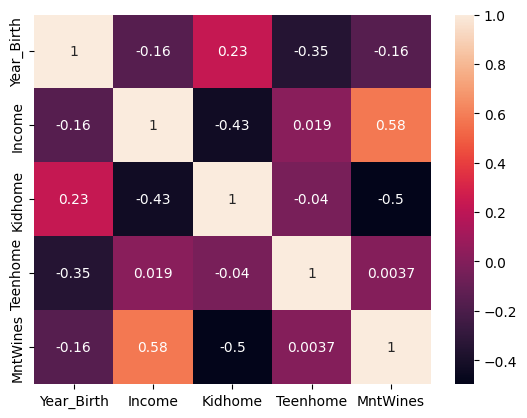

In [ ]:
# correleation plot of quantitative features

sns.heatmap(data[['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'MntWines']].corr(), annot=True)

<Axes: ylabel='Income'>

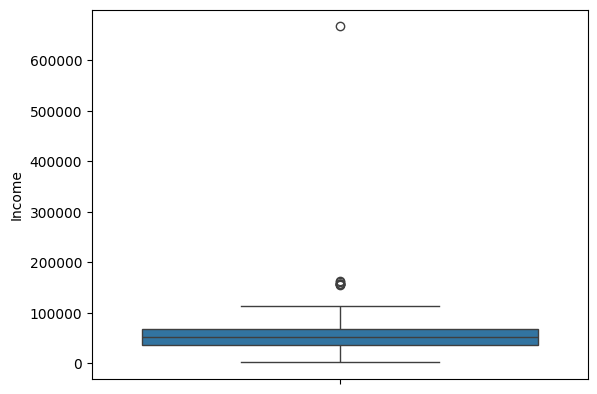

In [ ]:
# Boxplot of income

sns.boxplot(data, y="Income")

In [ ]:
# Filter the outier out

data = data[data['Income'] < 600000]

<Axes: ylabel='Income'>

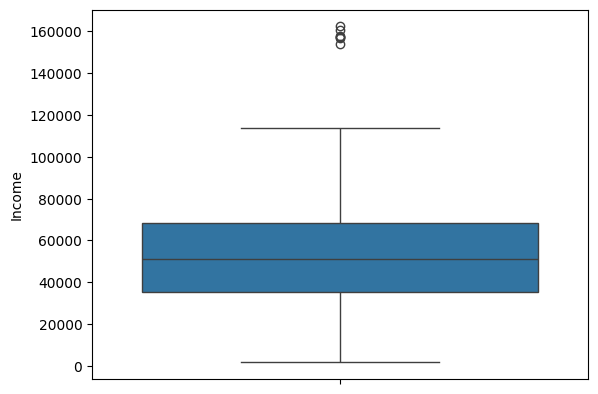

In [ ]:
# After filtering

sns.boxplot(data, y="Income")

<Axes: xlabel='Income', ylabel='MntWines'>

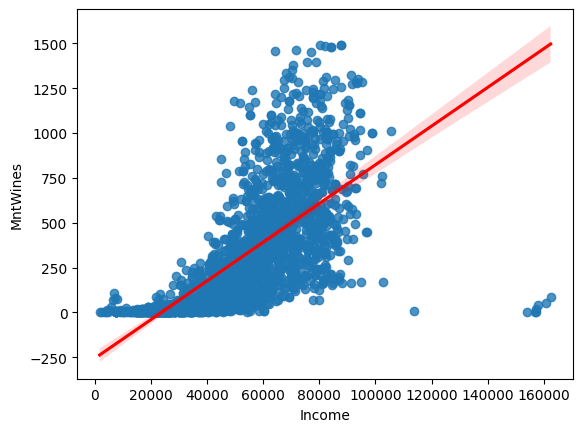

In [ ]:
# Regression plot of Income by Amount spent on wine

sns.regplot(data, x="Income", y="MntWines", line_kws={"color": "red"})

<Axes: xlabel='Kidhome', ylabel='MntWines'>

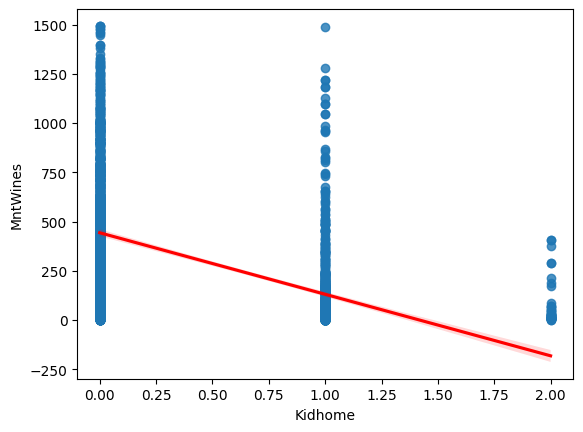

In [ ]:
# Create one of your own

sns.regplot(data, x="Kidhome", y="MntWines", line_kws={"color": "red"})

# compare to others

In [ ]:
# Education analysis

data['Education'].value_counts()

,count
Education,
Graduation,1115
PhD,481
Master,365
2n Cycle,200
Basic,54


<ipython-input-36-55619c82c902>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Graduation' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  edu_vs_wine.iloc[i,0] = educations[i]


<Axes: xlabel='Education', ylabel='Avg_spent_wine'>

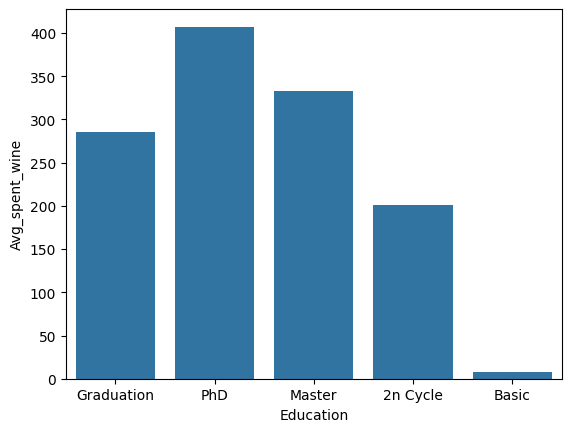

In [ ]:
# Plotting the averge amount spent on wine for each educational category

educations = list(data['Education'].value_counts().index)

edu_vs_wine = pd.DataFrame(np.zeros(shape=(5,2)), columns = ['Education', 'Avg_spent_wine'])

for i in range(len(educations)):
  edu_vs_wine.iloc[i,0] = educations[i]
  edu_vs_wine.iloc[i,1] = data[data['Education'] == educations[i]]['MntWines'].mean()


sns.barplot(edu_vs_wine, x='Education', y='Avg_spent_wine')


In [ ]:
# Marrital Status analysis

data['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,572
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [ ]:
valid_status = ['Married', 'Together', 'Single', 'Divorced', 'Widow']

data = data[data['Marital_Status'].isin(valid_status)]

<ipython-input-42-f73cbfe5526b>:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Married' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  status_vs_wine.iloc[i,0] = statuses[i]


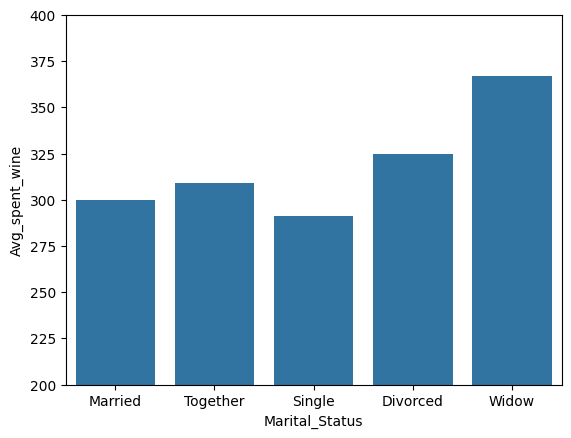

In [ ]:
statuses = list(data['Marital_Status'].value_counts().index)

status_vs_wine = pd.DataFrame(np.zeros(shape=(5,2)), columns = ['Marital_Status', 'Avg_spent_wine'])

for i in range(len(statuses)):
  status_vs_wine.iloc[i,0] = statuses[i]
  status_vs_wine.iloc[i,1] = data[data['Marital_Status'] == statuses[i]]['MntWines'].mean()


sns.barplot(status_vs_wine, x='Marital_Status', y='Avg_spent_wine')
plt.ylim(200,400)
plt.show()


# Pre-processing

In [ ]:
# creating dummy variables
data=data.reset_index()
encoder = OneHotEncoder()

marital_encoded = encoder.fit_transform(data[['Marital_Status']]).toarray()
marital_names = list(encoder.get_feature_names_out(['Marital_Status']))
marital_encoded_df = pd.DataFrame(marital_encoded, columns=marital_names)

education_encoded = encoder.fit_transform(data[['Education']]).toarray()
education_names = list(encoder.get_feature_names_out(['Education']))
education_encoded_df = pd.DataFrame(education_encoded, columns=education_names)

data_encoded = pd.concat([data, marital_encoded_df, education_encoded_df], axis=1)



In [ ]:
data_encoded.head()

,index,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,MntWines,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,0,5524,1957,Graduation,Single,58138.0,0,0,635,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,2174,1954,Graduation,Single,46344.0,1,1,11,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,4141,1965,Graduation,Together,71613.0,0,0,426,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,6182,1984,Graduation,Together,26646.0,1,0,11,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,5324,1981,PhD,Married,58293.0,1,0,173,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# feature selection
data_encoded_droped = data_encoded.drop(['index', 'ID', 'Education', 'Marital_Status'], axis=1)

In [ ]:
from sklearn import preprocessing

scaler = preprocessing.MinMaxScaler()

In [ ]:
# Describe data before normalization

data_encoded_droped.iloc[:,:6].describe()

,Year_Birth,Income,Kidhome,Teenhome,MntWines,Marital_Status_Divorced
count,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000
mean,1968.801630,51965.706975,0.441576,0.505435,305.328351,0.105072
std,11.982148,21543.449491,0.537014,0.544335,337.706216,0.306716
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35233.500000,0.000000,0.000000,24.000000,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,174.000000,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,505.500000,0.000000
max,1996.000000,162397.000000,2.000000,2.000000,1493.000000,1.000000


In [ ]:
model_data = data_encoded_droped
model_data.iloc[:,:6] = scaler.fit_transform(model_data.iloc[:,:6])

<ipython-input-49-16c8212c1a35>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.62135922 0.59223301 0.69902913 ... 0.85436893 0.61165049 0.59223301]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  model_data.iloc[:,:6] = scaler.fit_transform(model_data.iloc[:,:6])
<ipython-input-49-16c8212c1a35>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.  0.5 0.  ... 0.  0.  0.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  model_data.iloc[:,:6] = scaler.fit_transform(model_data.iloc[:,:6])
<ipython-input-49-16c8212c1a35>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.  0.5 0.  ... 0.  0.5 0.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  mod

In [ ]:
# After normalization

model_data.describe()

,Year_Birth,Income,Kidhome,Teenhome,MntWines,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
count,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000
mean,0.735938,0.312670,0.220788,0.252717,0.204507,0.105072,0.388134,0.213315,0.259058,0.034420,0.090580,0.024457,0.504076,0.164402,0.216486
std,0.116332,0.134088,0.268507,0.272167,0.226193,0.306716,0.487436,0.409741,0.438217,0.182347,0.287076,0.154497,0.500097,0.370724,0.411942
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.640777,0.208528,0.000000,0.000000,0.016075,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.747573,0.309034,0.000000,0.000000,0.116544,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.815534,0.415717,0.500000,0.500000,0.338580,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Setting up tsne object
tsne = TSNE(n_components = 3)

# output is 2d array of 3 vectors
tsne_data = tsne.fit_transform(model_data)

In [ ]:
data['tsne1'] = tsne_data[:,0]
data['tsne2'] = tsne_data[:,1]
data['tsne3'] = tsne_data[:,2]

px.scatter_3d(data, x='tsne1', y='tsne2', z='tsne3').show()

# Clustering

Text(0.5, 1.0, 'Inertia Values Over Amount of Clusters')

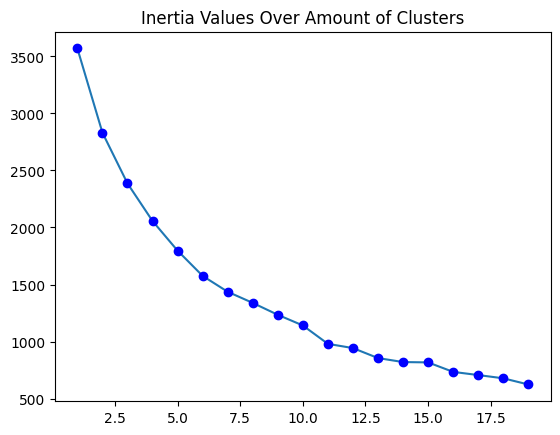

In [ ]:
# selecting the optimal number of clusters
inertias = []

for i in range(1,20):
  kmeans = KMeans(n_clusters=i, init='random', n_init='auto', random_state=21)
  kmeans.fit(model_data)
  inertias.append(kmeans.inertia_)

ax = sns.lineplot(x=range(1,20), y=inertias)
ax.plot(range(1, 20), inertias, 'o', color='b')
ax.set_title('Inertia Values Over Amount of Clusters')

In [ ]:
# Running the final model and clustering the dataset

kmeans_final = KMeans(n_clusters=20, init='random', n_init='auto', random_state=21)
kmeans_final.fit(model_data)


data['cluster'] = kmeans_final.predict(model_data).astype(str)

Text(0.5, 1.0, 'Sample Count per Cluster')

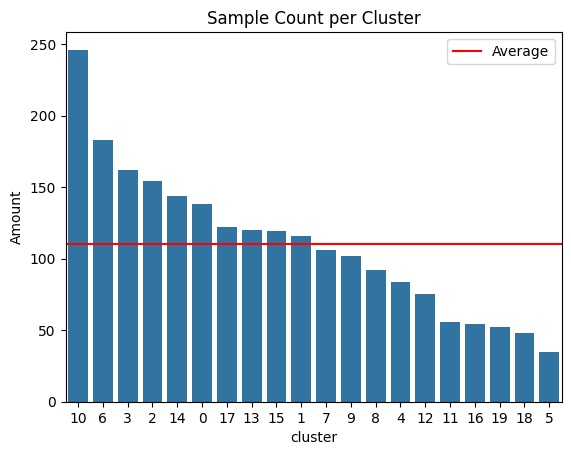

In [ ]:
# How many samples belong to each cluster

proportion = data['cluster'].value_counts()

ax2 = sns.barplot(x=proportion.index, y=proportion.values)
ax2.set_ylabel('Amount')
ax2.axhline(proportion.mean(), color='red', linestyle='-', label='Average')
ax2.legend()
ax2.set_title('Sample Count per Cluster')

In [ ]:
# tnse representation when colored by cluster

px.scatter_3d(data, x='tsne1', y='tsne2', z='tsne3', color='cluster').show()

# Cluster Analysis

In [ ]:
# Average amont spent on wine per cluster

clusters = list(data['cluster'].unique())
avgwine = []

for i in range(len(clusters)):
  clusteri = data[data['cluster'] == clusters[i]]
  avgwine.append(clusteri['MntWines'].mean())

Text(0, 0.5, 'Average Spent On Wines')

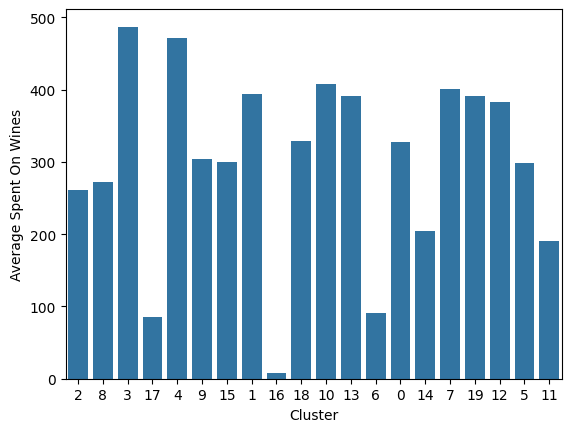

In [ ]:
AW = sns.barplot(x=clusters, y=avgwine)
AW.set_xlabel('Cluster')
AW.set_ylabel('Average Spent On Wines')

In [ ]:
# Subset data for just the best cluster
best = data[data['cluster'] == '3']

# best means
best.describe().iloc[1,2:]

,mean
Year_Birth,1965.432099
Income,65747.728395
Kidhome,0.006173
Teenhome,0.555556
MntWines,487.203704
tsne1,8.884480
tsne2,-8.772501
tsne3,-8.753448


In [ ]:
#Overall means
data.describe().iloc[1,2:]

,mean
Year_Birth,1968.801630
Income,51965.706975
Kidhome,0.441576
Teenhome,0.505435
MntWines,305.328351
tsne1,-0.403353
tsne2,0.205113
tsne3,0.128433


In [ ]:
print(best['Education'].value_counts())
print(best['Marital_Status'].value_counts())

Education
PhD    106
Name: count, dtype: int64
Marital_Status
Married    106
Name: count, dtype: int64


In [ ]:
# Describe the 2nd best cluster

second = data[data['cluster'] == '4']

second.describe().iloc[1,2:]

,mean
Year_Birth,1972.047619
Income,60160.214286
Kidhome,0.428571
Teenhome,0.000000
MntWines,471.000000
tsne1,-10.356999
tsne2,11.167592
tsne3,6.160264
